In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import VarianceThreshold

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
target = "Survived"

In [7]:
df.duplicated().sum()

0

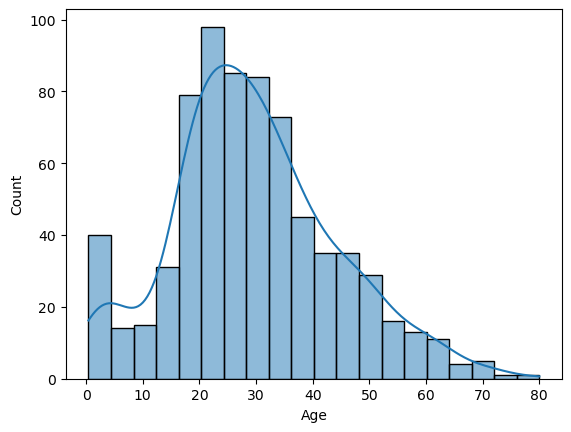

In [8]:
sns.histplot(df["Age"], kde=True)
plt.show()

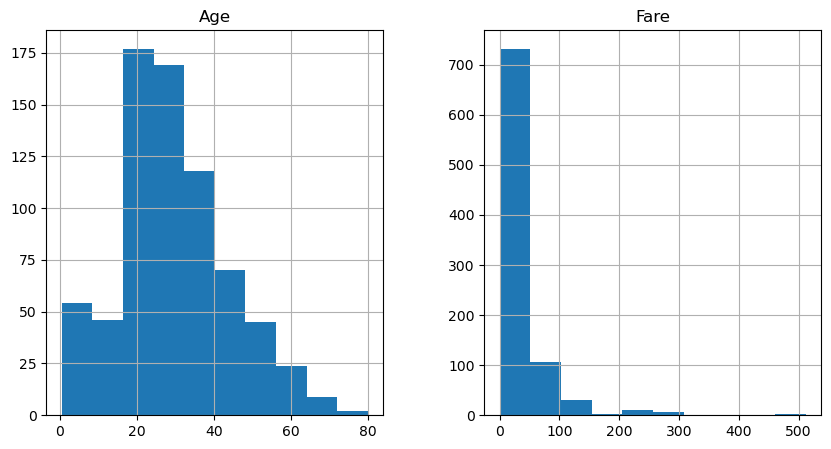

In [9]:
df[["Age","Fare"]].hist(figsize=(10,5))
plt.show()

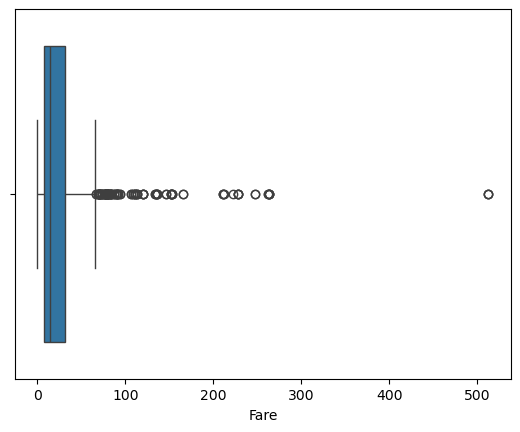

In [10]:
sns.boxplot(x=df["Fare"])
plt.show()

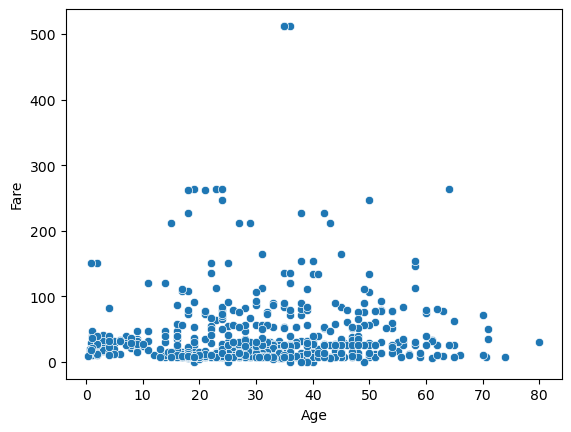

In [11]:
sns.scatterplot(x="Age", y="Fare", data=df)
plt.show()

In [12]:
corr = df.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


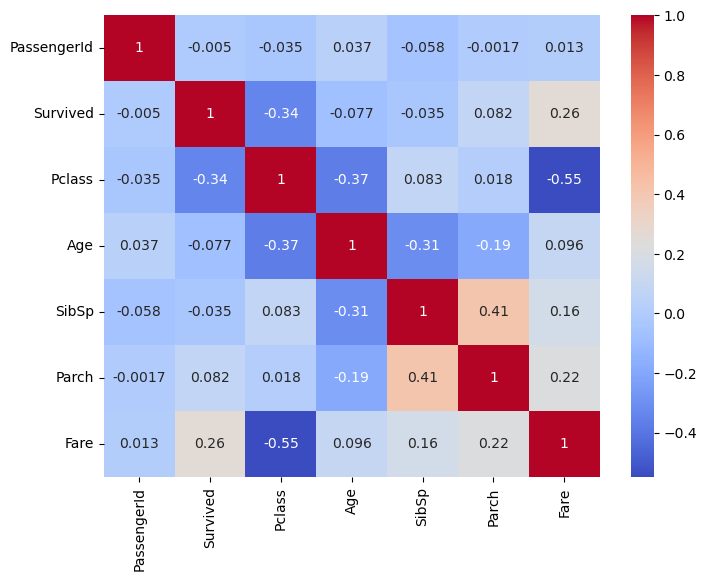

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [14]:
corr["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [15]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [16]:
X = X.drop(["PassengerId","Name","Ticket","Cabin"], axis=1)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
num_features = ["Age","Fare","SibSp","Parch"]
cat_features = ["Sex","Embarked","Pclass"]

In [19]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [20]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder())
])

In [21]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [22]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

In [23]:
poly = PolynomialFeatures(degree=2)

In [24]:
selector = SelectKBest(k=5)

In [25]:
variance = VarianceThreshold(threshold=0.1)


In [26]:
pca = PCA(n_components=5)

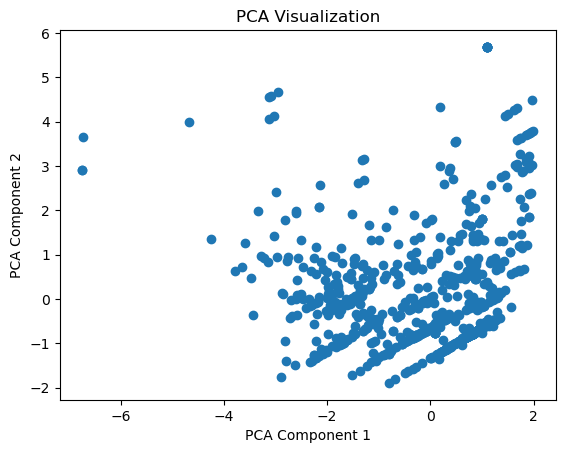

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# select numerical columns
X_num = X.select_dtypes(include=np.number)

# handle missing values
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_num)

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# apply PCA
pca_model = PCA(n_components=2)
X_pca = pca_model.fit_transform(X_scaled)

# visualize PCA
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [29]:
log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression())
])

log_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
tree_model = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier())
])

tree_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier())
])

rf_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
svm_model = Pipeline([
    ("prep", preprocessor),
    ("model", SVC())
])

svm_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
pred = rf_model.predict(X_test)

In [34]:
accuracy_score(y_test, pred)

0.8044692737430168

In [35]:
confusion_matrix(y_test, pred)

array([[88, 17],
       [18, 56]], dtype=int64)

In [36]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       105
           1       0.77      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [37]:
scores = cross_val_score(rf_model, X, y, cv=5)
scores.mean()

0.8092272926997677

In [38]:
param_grid = {
    "model__n_estimators":[50,100,200],
    "model__max_depth":[3,5,10]
}

grid = GridSearchCV(rf_model, param_grid, cv=5)
grid.fit(X_train, y_train)

grid.best_params_

{'model__max_depth': 5, 'model__n_estimators': 50}

In [41]:
random = RandomizedSearchCV(rf_model, param_grid, cv=5)
random.fit(X_train, y_train)

C:\Users\gsrav\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'model__max_depth': [3, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


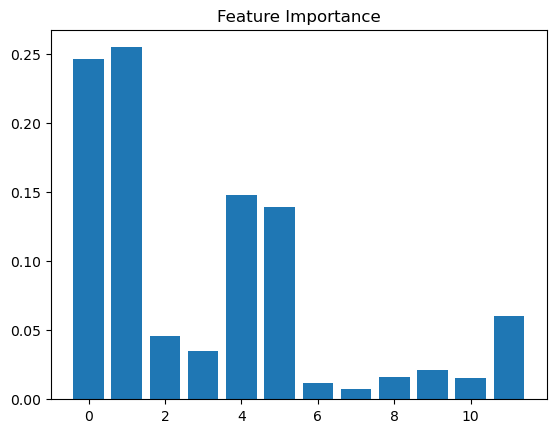

In [42]:
model = rf_model.named_steps["model"]

importances = model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

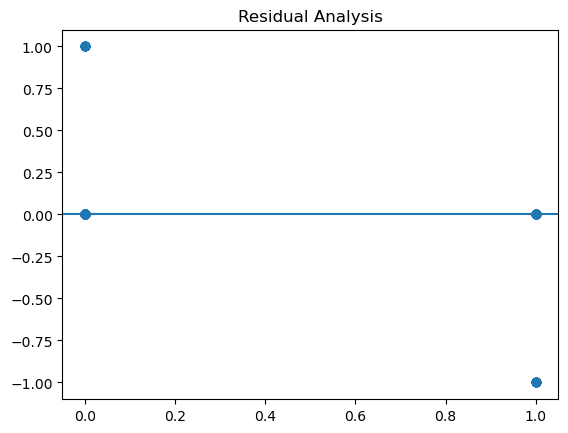

In [43]:
residuals = y_test - pred

plt.scatter(pred, residuals)
plt.axhline(0)
plt.title("Residual Analysis")
plt.show()